In [1]:
from __future__ import print_function
import os
import sys

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

# Import necessary torch libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models

# Import Model
from models.state_of_the_art_model.RESNET_18_CKPT import CheckpointedModel

# Import utils
from utils.train_val_utils import train_and_evaluate
from utils.dataloader_utils import dataloader
from utils.display_image_utils import display_original_vs_augmented
from utils.show_best_model_utils import show_best_model
from utils.load_best_model_utils import load_best_model
from utils.retrieve_results_from_ckpt_utils import results_from_ckpt
from utils.plot_train_val_curve_utils import plot_training_curves

# Set random seed for reproducibility
torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [3]:
# Tensor conversion
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets and dataloaders without augmentation for training dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform,
    transform_eval=transform,
    batch_size=32,
    num_workers=4
)

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


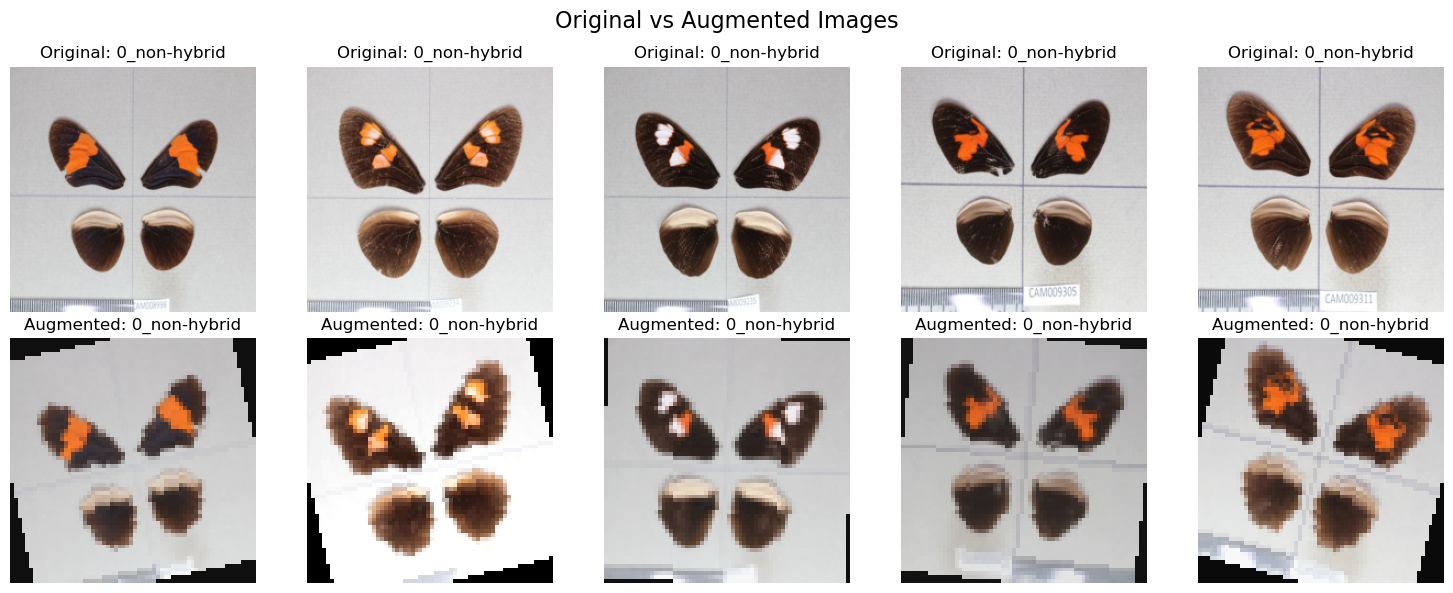

In [4]:
# Data augmentation transforms for training dataset
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Data augmentation transforms for validation and test datasets (only resizing and tensor conversion)
transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Load datasets and dataloaders with augmentation for training dataset
train_dataset_aug, val_dataset, test_dataset, train_loader_aug, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform_train,
    transform_eval=transform_eval,
    batch_size=32,
    num_workers=4
)

assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

display_original_vs_augmented(train_dataset, train_dataset_aug)

In [ ]:
learning_rate_values = [0.01, 0.005, 0.001, 0.0001]
weight_decay_values = [1e-3, 1e-4, 1e-5, 1e-6]
class_weights_values = [2.5, 3.5, 4.5, 5.5]
batch_size_values = [16, 32, 64, 128]

model_resnet_18_dict = {}
optimizer_18_dict = {}
results_18_dict = {}
best_18_dict = {}
best_f2_18_dict = {}

count = 1

best_learning_rate_dict = {}
best_weight_decay_dict = {}
best_class_weights_val_dict = {}
best_batch_size_dict = {}

best_learning_rate = 0.01
best_weight_decay = 1e-3
best_class_weights_val = 2.5
best_batch_size = 16

best_f2 = float("-inf")

# hyperparameter tuning for learning rate
for learning_rate in learning_rate_values:
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    base_model.fc = nn.Linear(base_model.fc.in_features, 2)
    model_resnet_18_dict[f"model_resnet_18_{count}"] = CheckpointedModel(base_model).to(device)
    optimizer_18_dict[f"optimizer_18_{count}"] = optim.Adam(model_resnet_18_dict[f"model_resnet_18_{count}"].parameters(), lr=learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model 18_{count} with learning rate {learning_rate}")
    results_18_dict[f"results_18_{count}"] = train_and_evaluate(model_resnet_18_dict[f"model_resnet_18_{count}"], train_dataset_aug, val_dataset, optimizer_18_dict[f"optimizer_18_{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{count}_log.pkl", device=device, num_workers=0)
    best_18_dict[f"best_18_{count}"], best_f2_18_dict[f"best_f2_18_{count}"] = show_best_model(model_resnet_18_dict[f"model_resnet_18_{count}"], ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_18_{count}"] = learning_rate
    best_weight_decay_dict[f"best_weight_decay_18_{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_18_{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_18_{count}"] = best_batch_size
    count += 1
    if best_f2_18_dict[f"best_f2_18_{count-1}"] > best_f2:
        best_learning_rate = learning_rate
        best_f2 = best_f2_18_dict[f"best_f2_18_{count-1}"]

# hyperparameter tuning for weight decay
for weight_decay in weight_decay_values[1:]:
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    base_model.fc = nn.Linear(base_model.fc.in_features, 2)
    model_resnet_18_dict[f"model_resnet_18_{count}"] = CheckpointedModel(base_model).to(device)
    optimizer_18_dict[f"optimizer_18_{count}"] = optim.Adam(model_resnet_18_dict[f"model_resnet_18_{count}"].parameters(), lr=best_learning_rate, weight_decay=weight_decay)
    print(f"\nTraining RESNET Model 18_{count} with weight decay {weight_decay}")
    results_18_dict[f"results_18_{count}"] = train_and_evaluate(model_resnet_18_dict[f"model_resnet_18_{count}"], train_dataset_aug, val_dataset, optimizer_18_dict[f"optimizer_18_{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{count}_log.pkl", device=device, num_workers=0)
    best_18_dict[f"best_18_{count}"], best_f2_18_dict[f"best_f2_18_{count}"] = show_best_model(model_resnet_18_dict[f"model_resnet_18_{count}"], ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_18_{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_18_{count}"] = weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_18_{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_18_{count}"] = best_batch_size
    count += 1
    if best_f2_18_dict[f"best_f2_18_{count-1}"] > best_f2:
        best_weight_decay = weight_decay
        best_f2 = best_f2_18_dict[f"best_f2_18_{count-1}"]

# hyperparameter tuning for class weights
for class_weights_val in class_weights_values[1:]:
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    base_model.fc = nn.Linear(base_model.fc.in_features, 2)
    model_resnet_18_dict[f"model_resnet_18_{count}"] = CheckpointedModel(base_model).to(device)
    optimizer_18_dict[f"optimizer_18_{count}"] = optim.Adam(model_resnet_18_dict[f"model_resnet_18_{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model 18_{count} with class weights {class_weights_val}")
    results_18_dict[f"results_18_{count}"] = train_and_evaluate(model_resnet_18_dict[f"model_resnet_18_{count}"], train_dataset_aug, val_dataset, optimizer_18_dict[f"optimizer_18_{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{count}_log.pkl", device=device, num_workers=0)
    best_18_dict[f"best_18_{count}"], best_f2_18_dict[f"best_f2_18_{count}"] = show_best_model(model_resnet_18_dict[f"model_resnet_18_{count}"], ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_18_{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_18_{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_18_{count}"] = class_weights_val
    best_batch_size_dict[f"best_batch_size_18_{count}"] = best_batch_size
    count += 1
    if best_f2_18_dict[f"best_f2_18_{count-1}"] > best_f2:
        best_class_weights_val = class_weights_val
        best_f2 = best_f2_18_dict[f"best_f2_18_{count-1}"]

# hyperparameter tuning for batch size
for batch_size in batch_size_values[1:]:
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    base_model.fc = nn.Linear(base_model.fc.in_features, 2)
    model_resnet_18_dict[f"model_resnet_18_{count}"] = CheckpointedModel(base_model).to(device)
    optimizer_18_dict[f"optimizer_18_{count}"] = optim.Adam(model_resnet_18_dict[f"model_resnet_18_{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model 18_{count} with batch size {batch_size}")
    results_18_dict[f"results_18_{count}"] = train_and_evaluate(model_resnet_18_dict[f"model_resnet_18_{count}"], train_dataset_aug, val_dataset, optimizer_18_dict[f"optimizer_18_{count}"], num_epochs=30, batch_size=batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{count}_log.pkl", device=device, num_workers=0)
    best_18_dict[f"best_18_{count}"], best_f2_18_dict[f"best_f2_18_{count}"] = show_best_model(model_resnet_18_dict[f"model_resnet_18_{count}"], ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_18_{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_18_{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_18_{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_18_{count}"] = batch_size
    count += 1
    if best_f2_18_dict[f"best_f2_18_{count-1}"] > best_f2:
        best_batch_size = batch_size
        best_f2 = best_f2_18_dict[f"best_f2_18_{count-1}"]

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Stanley Tan/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 37.4MB/s]



Training RESNET Model 18_1 with learning rate 0.01
  [Epoch 1] Improvement! New best score: 0.511883
  [Epoch 2] Improvement! New best score: 0.644699
  [Epoch 3] Improvement! New best score: 0.732484
Epoch [5/30], Train Loss: 0.3177, Val Loss: 0.6751, Train F1-Macro: 0.6558, Val F1-Macro: 0.6676, Train F1-Per-Class: [0.7934585 0.5181347], Val F1-Per-Class: [0.80448717 0.5307692 ], Train F2-Macro: 0.7104, Val F2-Macro: 0.7226, Train F2-Per-Class: [0.7111835 0.7096774], Val F2-Per-Class: [0.72501445 0.72025055], No improvement: 2/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.3177, Val Loss: 0.6751, Train F1-Macro: 0.6558, Val F1-Macro: 0.6676, Train F1-Per-Class: [0.7934585 0.5181347], Val F1-Per-Class: [0.80448717 0.5307692 ] Train F2-Macro: 0.7104, Val F2-Macro: 0.7226, Train F2-Per-Class: [0.7111835 0.7096774], Val F2-Per-Class: [0.72501445 0.72025055]
  [Epoch 6] Improvement! New best score: 0.779037
  [Epoch 7] Improvement! New best score: 0.800562
  [Epoch 9] Improvement! New best 

In [5]:
# Restore best hyperparameters for Resnet-18
best_learning_rate_dict = {'best_learning_rate_18_1': 0.01, 'best_learning_rate_18_2': 0.005, 'best_learning_rate_18_3': 0.001, 'best_learning_rate_18_4': 0.0001, 'best_learning_rate_18_5': 0.0001, 'best_learning_rate_18_6': 0.0001, 'best_learning_rate_18_7': 0.0001, 'best_learning_rate_18_8': 0.0001, 'best_learning_rate_18_9': 0.0001, 'best_learning_rate_18_10': 0.0001, 'best_learning_rate_18_11': 0.0001, 'best_learning_rate_18_12': 0.0001, 'best_learning_rate_18_13': 0.0001}
best_weight_decay_dict = {'best_weight_decay_18_1': 0.001, 'best_weight_decay_18_2': 0.001, 'best_weight_decay_18_3': 0.001, 'best_weight_decay_18_4': 0.001, 'best_weight_decay_18_5': 0.0001, 'best_weight_decay_18_6': 1e-05, 'best_weight_decay_18_7': 1e-06, 'best_weight_decay_18_8': 0.0001, 'best_weight_decay_18_9': 0.0001, 'best_weight_decay_18_10': 0.0001, 'best_weight_decay_18_11': 0.0001, 'best_weight_decay_18_12': 0.0001, 'best_weight_decay_18_13': 0.0001}
best_class_weights_val_dict = {'best_class_weights_val_18_1': 2.5, 'best_class_weights_val_18_2': 2.5, 'best_class_weights_val_18_3': 2.5, 'best_class_weights_val_18_4': 2.5, 'best_class_weights_val_18_5': 2.5, 'best_class_weights_val_18_6': 2.5, 'best_class_weights_val_18_7': 2.5, 'best_class_weights_val_18_8': 3.5, 'best_class_weights_val_18_9': 4.5, 'best_class_weights_val_18_10': 5.5, 'best_class_weights_val_18_11': 5.5, 'best_class_weights_val_18_12': 5.5, 'best_class_weights_val_18_13': 5.5}
best_batch_size_dict = {'best_batch_size_18_1': 16, 'best_batch_size_18_2': 16, 'best_batch_size_18_3': 16, 'best_batch_size_18_4': 16, 'best_batch_size_18_5': 16, 'best_batch_size_18_6': 16, 'best_batch_size_18_7': 16, 'best_batch_size_18_8': 16, 'best_batch_size_18_9': 16, 'best_batch_size_18_10': 16, 'best_batch_size_18_11': 32, 'best_batch_size_18_12': 64, 'best_batch_size_18_13': 128}

# Initialize model_resnet_18_dict with ResNet instances for each hyperparameter combination
def make_resnet18():
    base_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    base_model.fc = nn.Linear(base_model.fc.in_features, 2)
    return CheckpointedModel(base_model).to(device)

model_resnet_18_dict = {
    "model_resnet_18_1": make_resnet18(),
    "model_resnet_18_2": make_resnet18(),
    "model_resnet_18_3": make_resnet18(),
    "model_resnet_18_4": make_resnet18(),
    "model_resnet_18_5": make_resnet18(),
    "model_resnet_18_6": make_resnet18(),
    "model_resnet_18_7": make_resnet18(),
    "model_resnet_18_8": make_resnet18(),
    "model_resnet_18_9": make_resnet18(),
    "model_resnet_18_10": make_resnet18(),
    "model_resnet_18_11": make_resnet18(),
    "model_resnet_18_12": make_resnet18(),
    "model_resnet_18_13": make_resnet18(),
    "model_resnet_18_14": make_resnet18(),
    "model_resnet_18_15": make_resnet18(),
    "model_resnet_18_16": make_resnet18(),
}

best_18_dict = {}
best_f2_18_dict = {}

In [6]:
for i in range(1, 8):
    print(
        f"Model ResNet-18_{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_18_{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_18_{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_18_{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_18_{i}']}"
    )
    best_18_dict[f"best_18_{i}"], best_f2_18_dict[f"best_f2_18_{i}"] = show_best_model(model=model_resnet_18_dict[f"model_resnet_18_{i}"], ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{i}_log.pkl")

Model ResNet-18_1 | lr=0.01 | wd=0.001 | class_w=2.5 | bs=16
Selected epoch: 9
Best val F2(class 0): 0.8723523020744324
Best val F2(class 1): 0.817307710647583
Model ResNet-18_2 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=16
Selected epoch: 17
Best val F2(class 0): 0.9766049981117249
Best val F2(class 1): 0.9408602118492126
Model ResNet-18_3 | lr=0.001 | wd=0.001 | class_w=2.5 | bs=16
Selected epoch: 4
Best val F2(class 0): 0.9831613302230835
Best val F2(class 1): 0.9485095143318176
Model ResNet-18_4 | lr=0.0001 | wd=0.001 | class_w=2.5 | bs=16
Selected epoch: 9
Best val F2(class 0): 0.988056480884552
Best val F2(class 1): 0.9646739363670349
Model ResNet-18_5 | lr=0.0001 | wd=0.0001 | class_w=2.5 | bs=16
Selected epoch: 13
Best val F2(class 0): 0.9842305779457092
Best val F2(class 1): 0.9703503847122192
Model ResNet-18_6 | lr=0.0001 | wd=1e-05 | class_w=2.5 | bs=16
Selected epoch: 7
Best val F2(class 0): 0.9793253540992737
Best val F2(class 1): 0.9543010592460632
Model ResNet-18_7 | lr=0.

In [7]:
for i in range(8, 14):
    print(
        f"Model ResNet-18_{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_18_{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_18_{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_18_{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_18_{i}']}"
    )
    best_18_dict[f"best_18_{i}"], best_f2_18_dict[f"best_f2_18_{i}"] = show_best_model(model=model_resnet_18_dict[f"model_resnet_18_{i}"], ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{i}_log.pkl")

Model ResNet-18_8 | lr=0.0001 | wd=0.0001 | class_w=3.5 | bs=16
Selected epoch: 4
Best val F2(class 0): 0.9815117120742798
Best val F2(class 1): 0.9568732976913452
Model ResNet-18_9 | lr=0.0001 | wd=0.0001 | class_w=4.5 | bs=16
Selected epoch: 9
Best val F2(class 0): 0.990233302116394
Best val F2(class 1): 0.9673024415969849
Model ResNet-18_10 | lr=0.0001 | wd=0.0001 | class_w=5.5 | bs=16
Selected epoch: 13
Best val F2(class 0): 0.9760087132453918
Best val F2(class 1): 0.9707446694374084
Model ResNet-18_11 | lr=0.0001 | wd=0.0001 | class_w=5.5 | bs=32
Selected epoch: 21
Best val F2(class 0): 0.9869494438171387
Best val F2(class 1): 0.9838274717330933
Model ResNet-18_12 | lr=0.0001 | wd=0.0001 | class_w=5.5 | bs=64
Selected epoch: 12
Best val F2(class 0): 0.9798584580421448
Best val F2(class 1): 0.9651474356651306
Model ResNet-18_13 | lr=0.0001 | wd=0.0001 | class_w=5.5 | bs=128
Selected epoch: 22
Best val F2(class 0): 0.9869494438171387
Best val F2(class 1): 0.9838274717330933


In [8]:
# Pick the model index with highest validation F2 (class 1) among all collected runs
best_f2_key = max(best_f2_18_dict, key=lambda k: float(best_f2_18_dict[k]))
best_i = int(best_f2_key.rsplit("_", 1)[-1])   # "best_f2_18_11" -> "11"

model = model_resnet_18_dict[f"model_resnet_18_{best_i}"]
best = best_18_dict[f"best_18_{best_i}"]

print(
    f"Selected Best Model ResNet-18_{best_i} | "
    f"val_f2_class1={float(best_f2_18_dict[best_f2_key]):.6f} | "
    f"lr={best_learning_rate_dict[f'best_learning_rate_18_{best_i}']} | "
    f"wd={best_weight_decay_dict[f'best_weight_decay_18_{best_i}']} | "
    f"class_w={best_class_weights_val_dict[f'best_class_weights_val_18_{best_i}']}"
)

load_best_model(best_model=model, best=best, test_dataset=test_dataset, device=device)

Selected Best Model ResNet-18_11 | val_f2_class1=0.983827 | lr=0.0001 | wd=0.0001 | class_w=5.5
Test loss: 0.05890210950799103
Test F2 macro: 0.9671443104743958
Test F2 per class: [0.97938144 0.9549072 ]
Test F2 for class 1 (1_hybrid): 0.9549071788787842


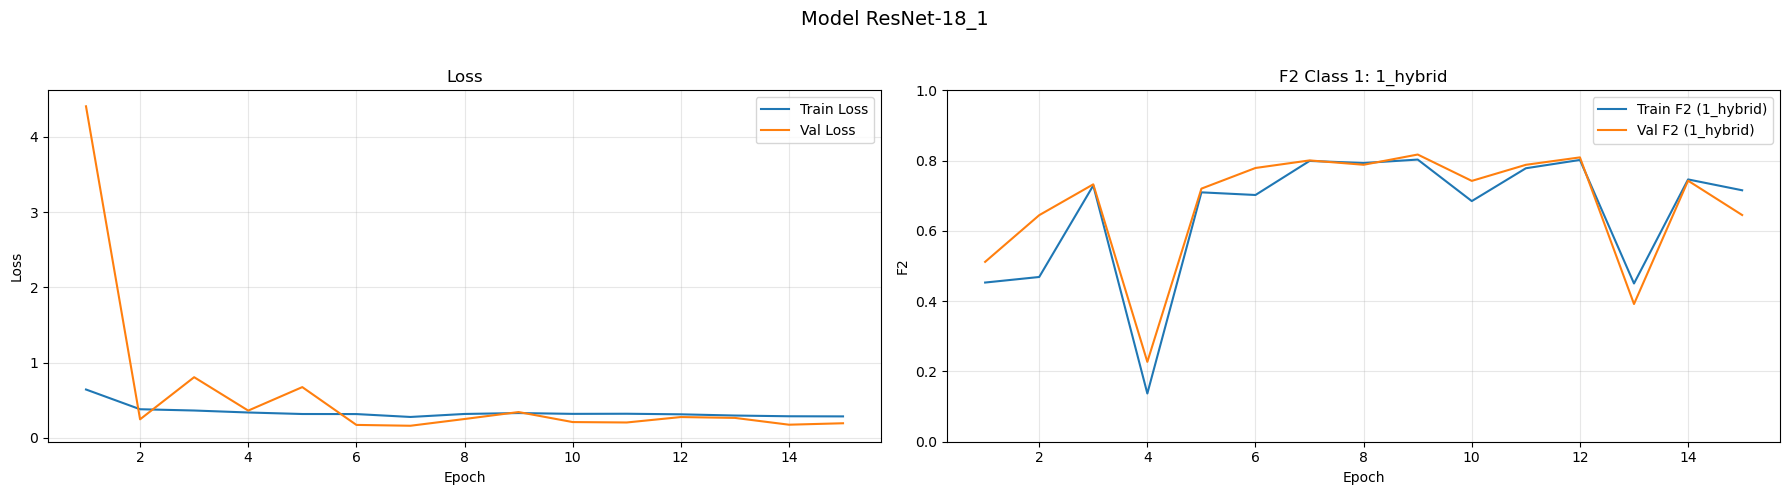

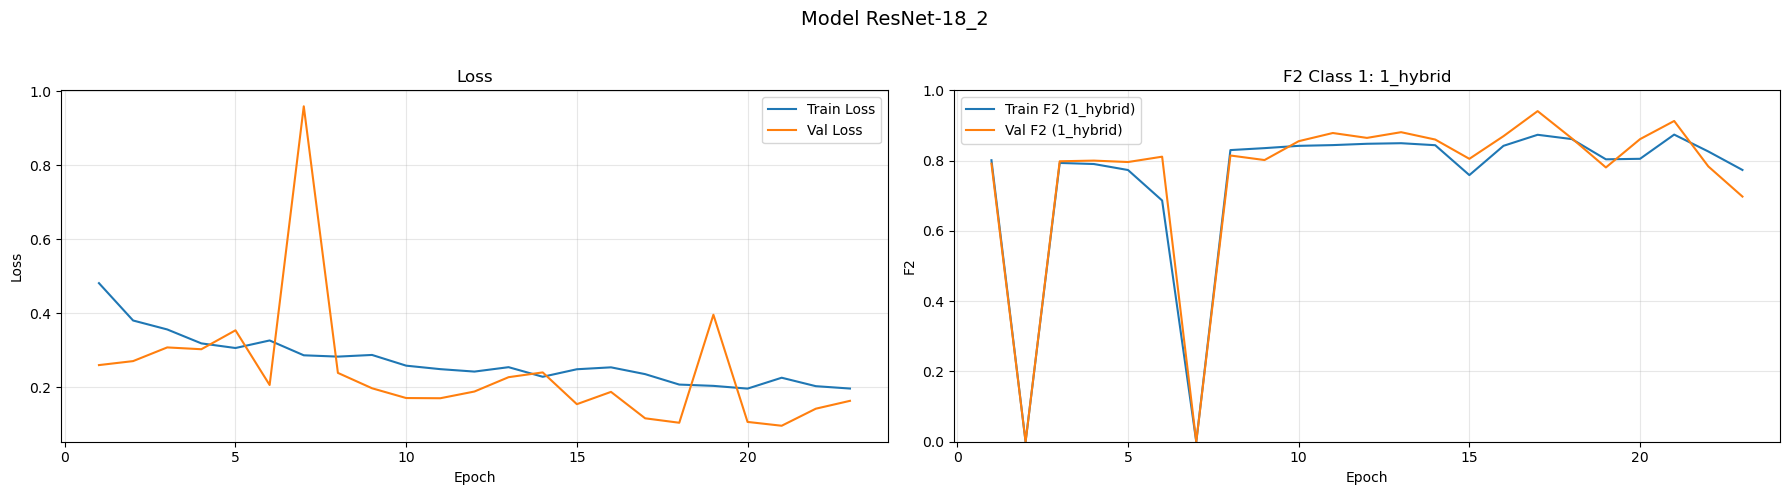

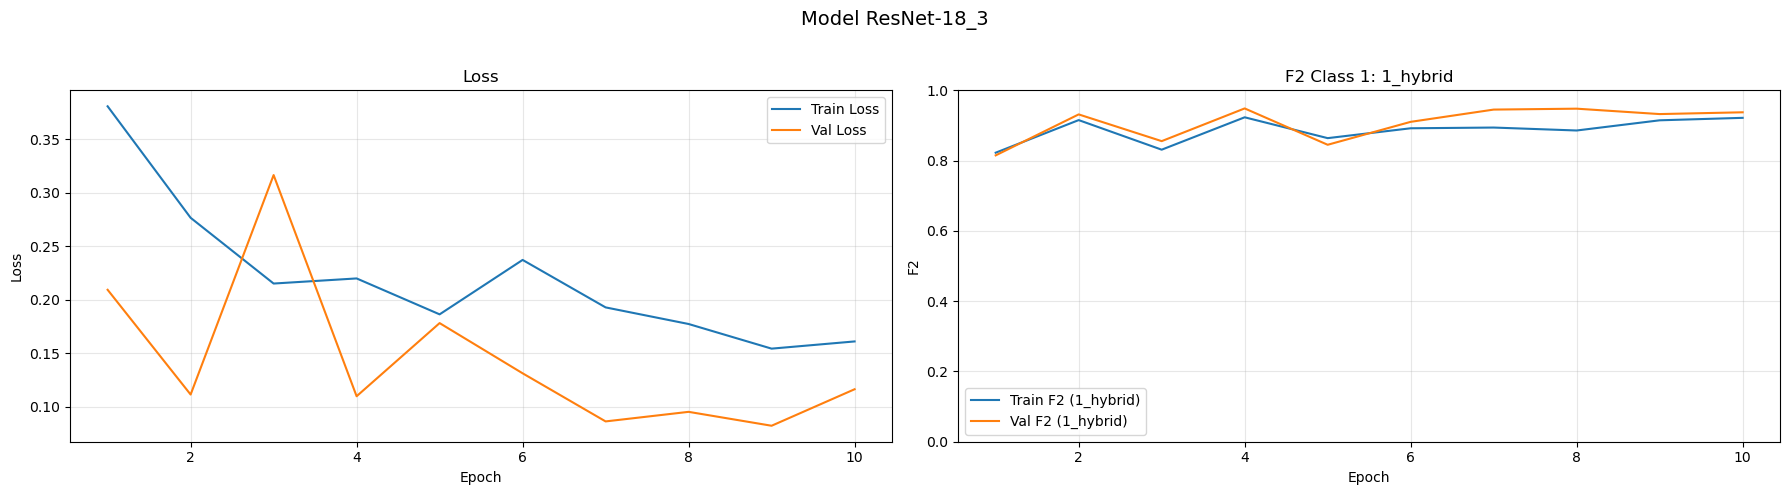

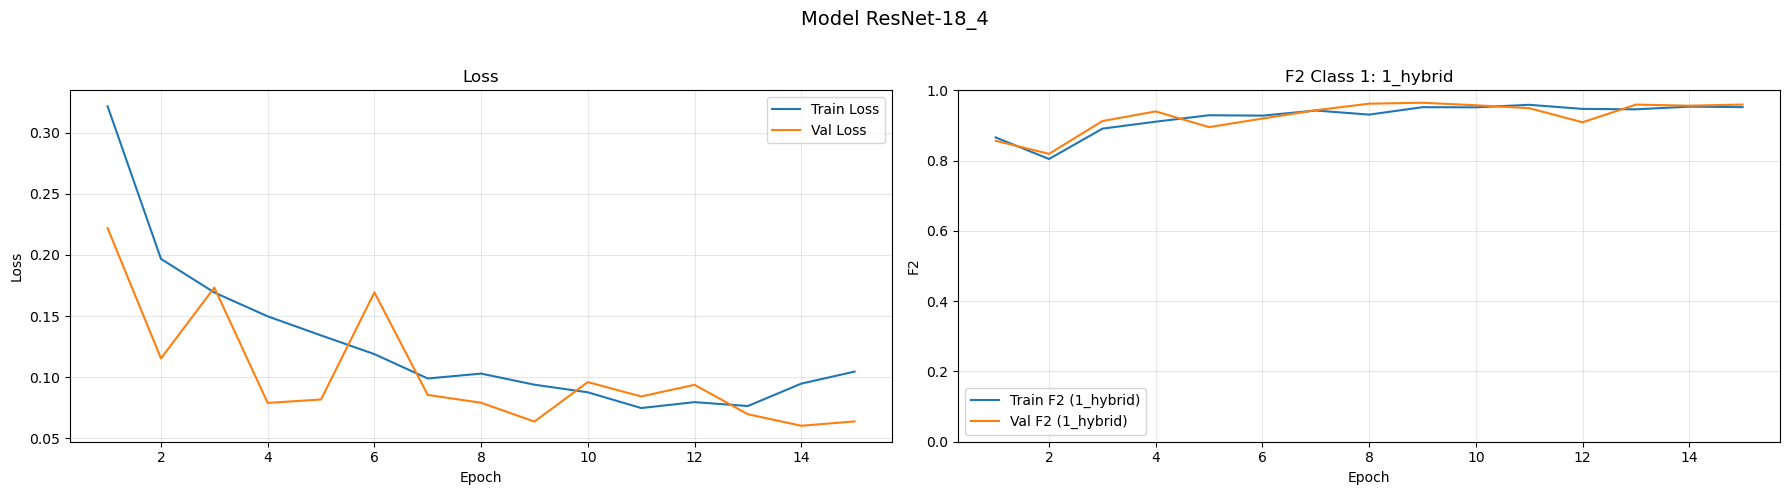

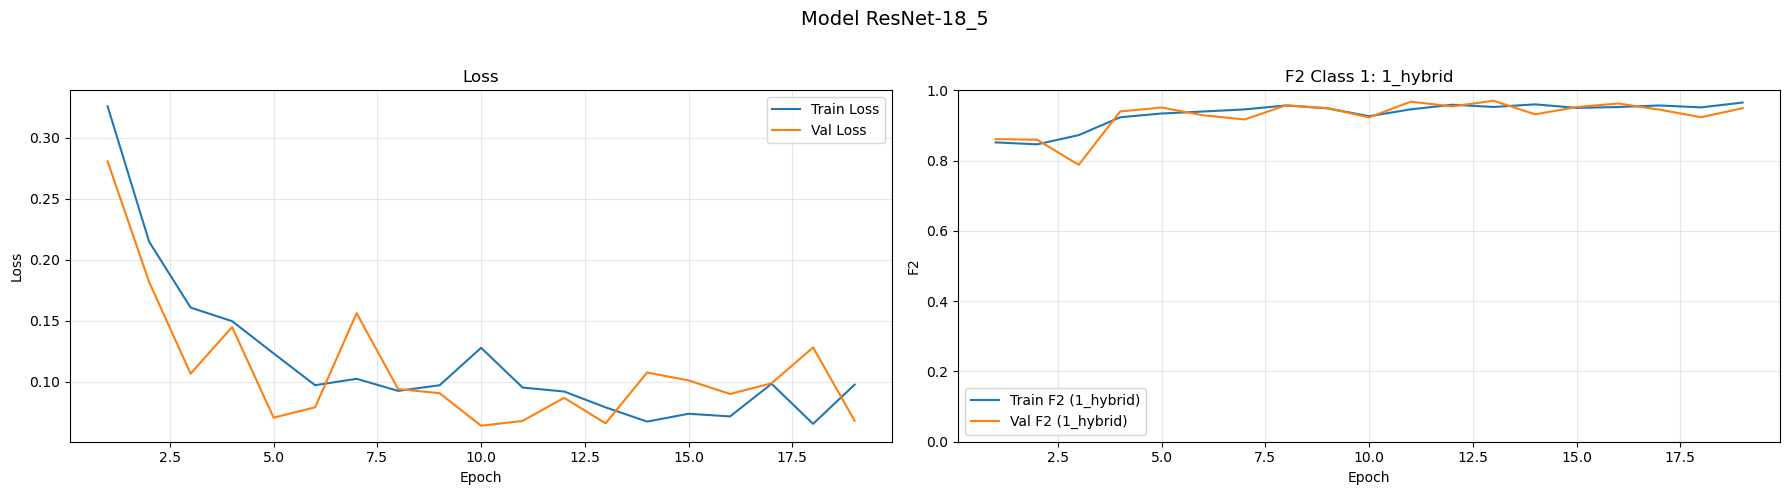

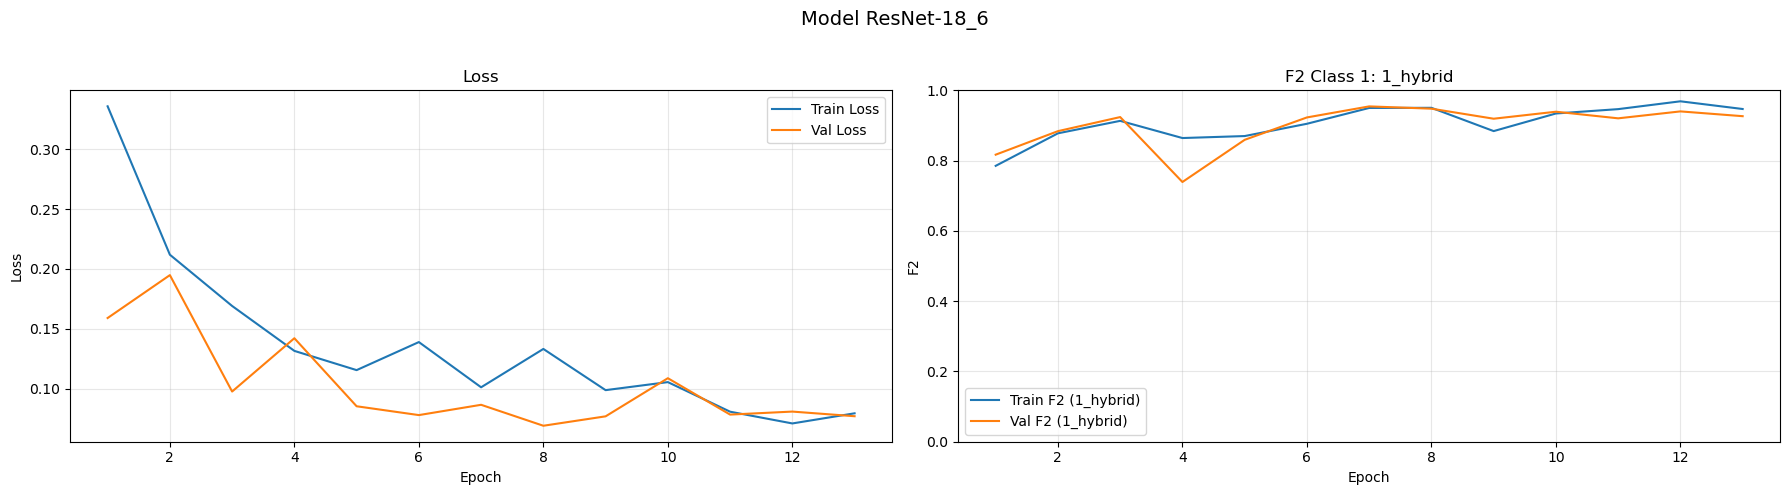

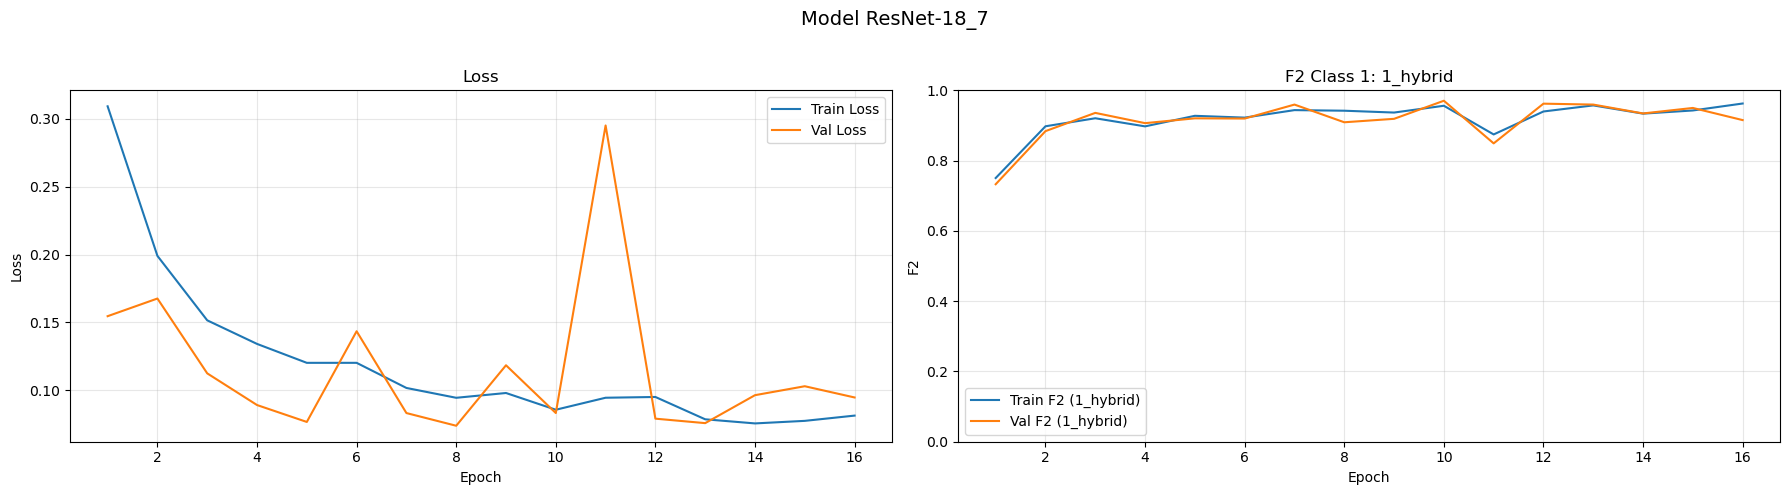

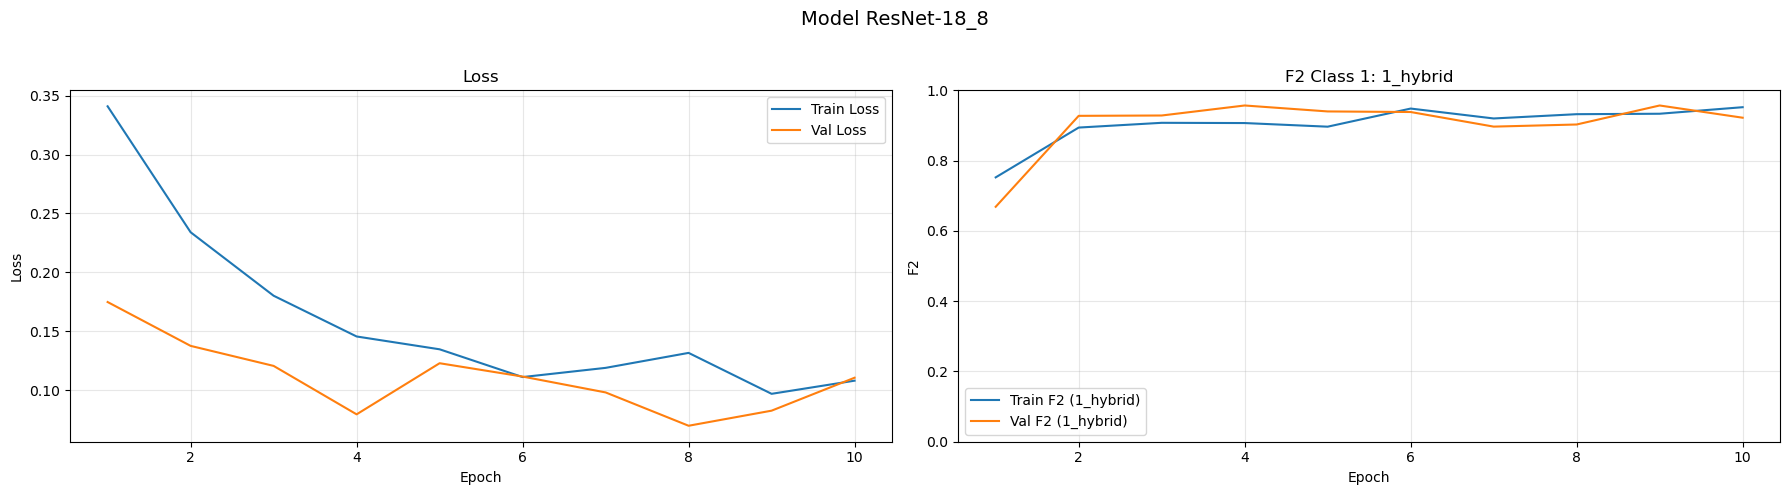

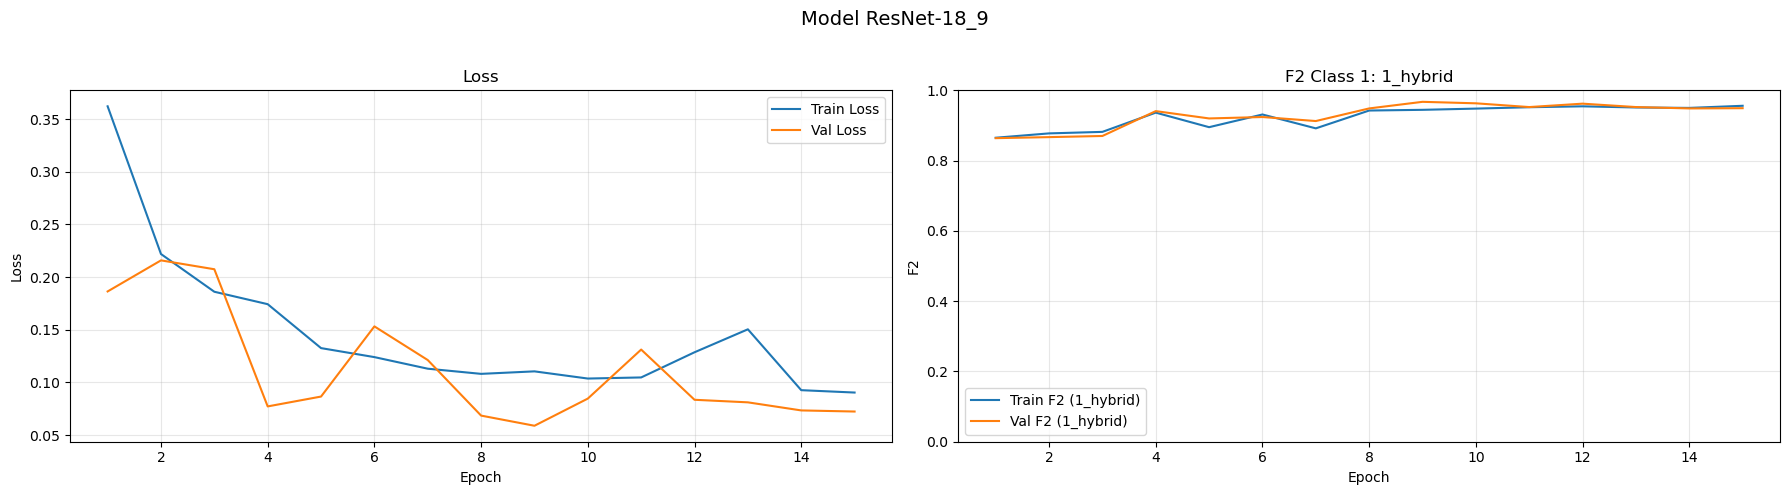

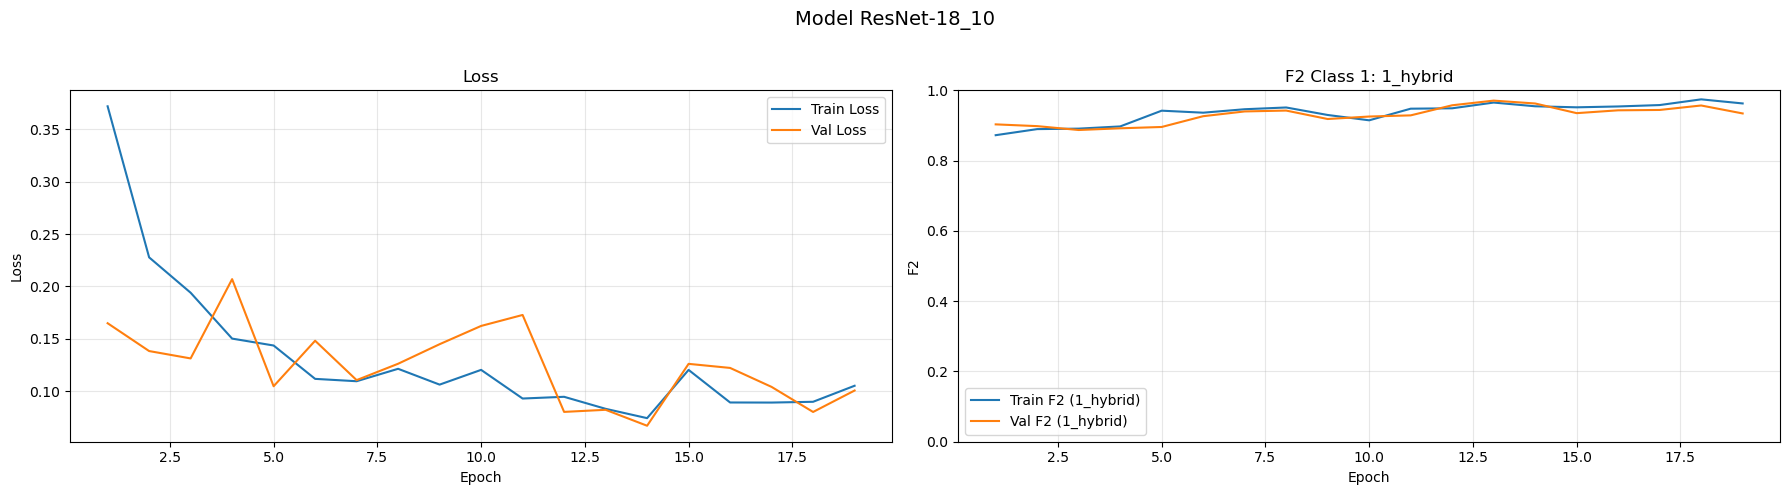

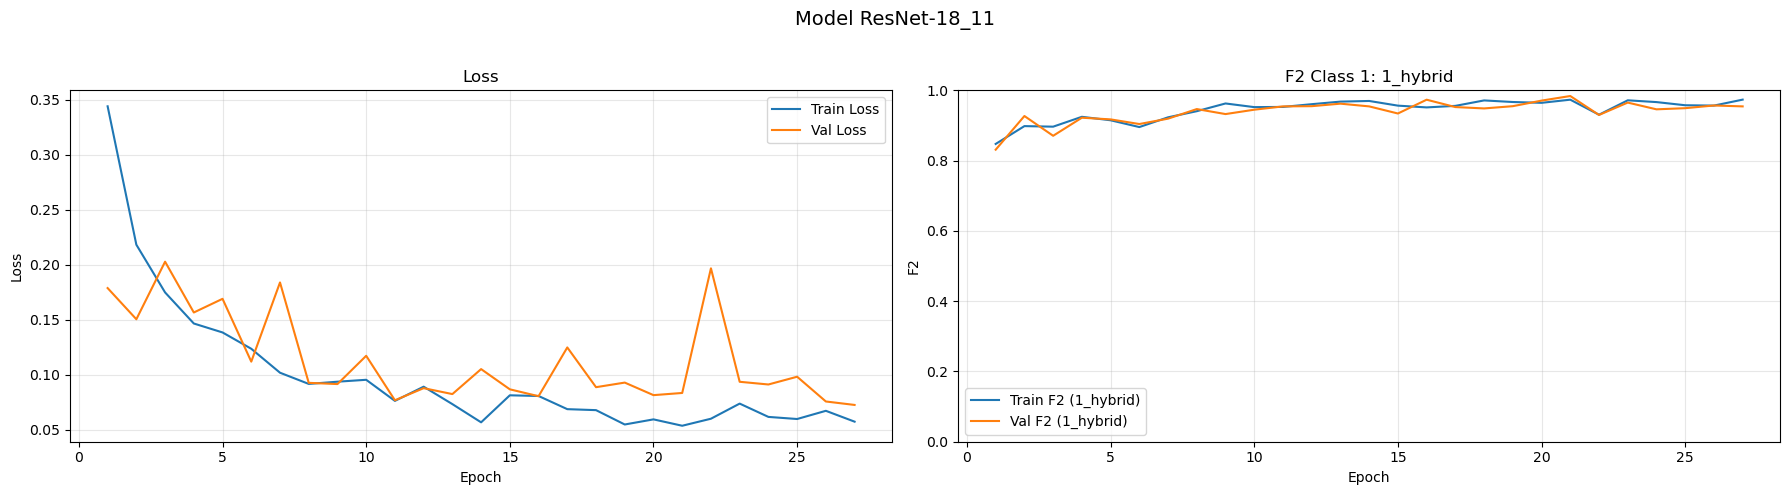

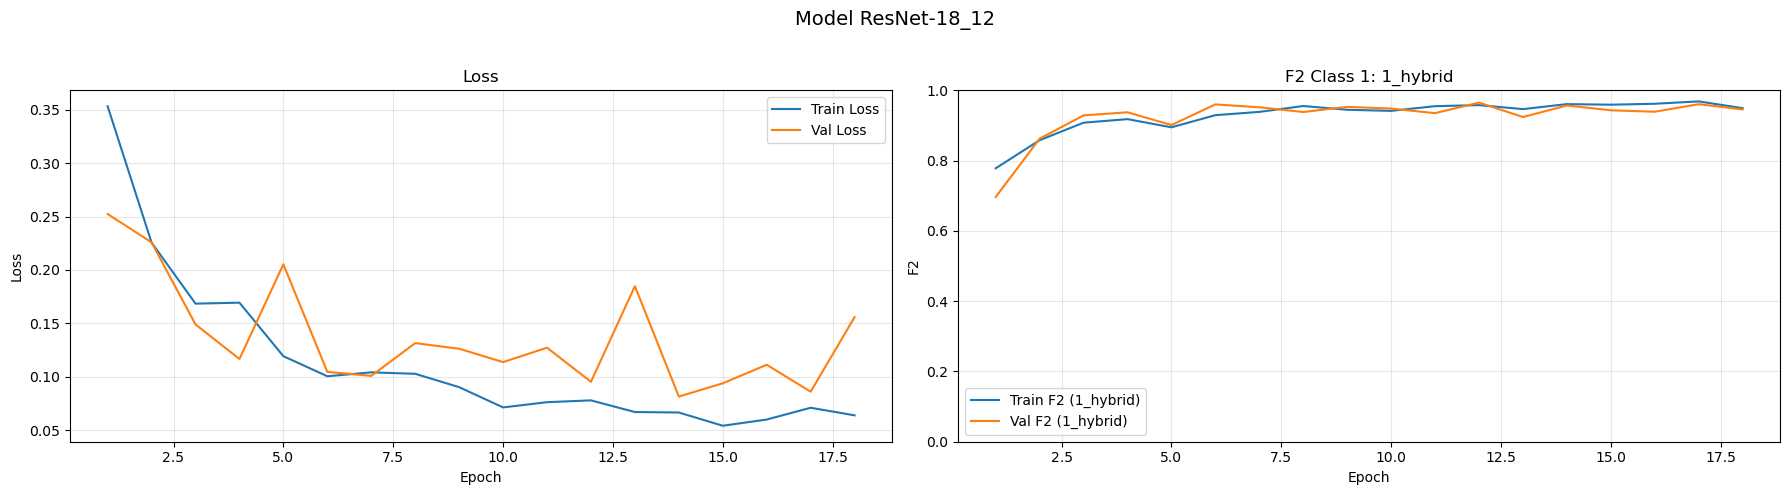

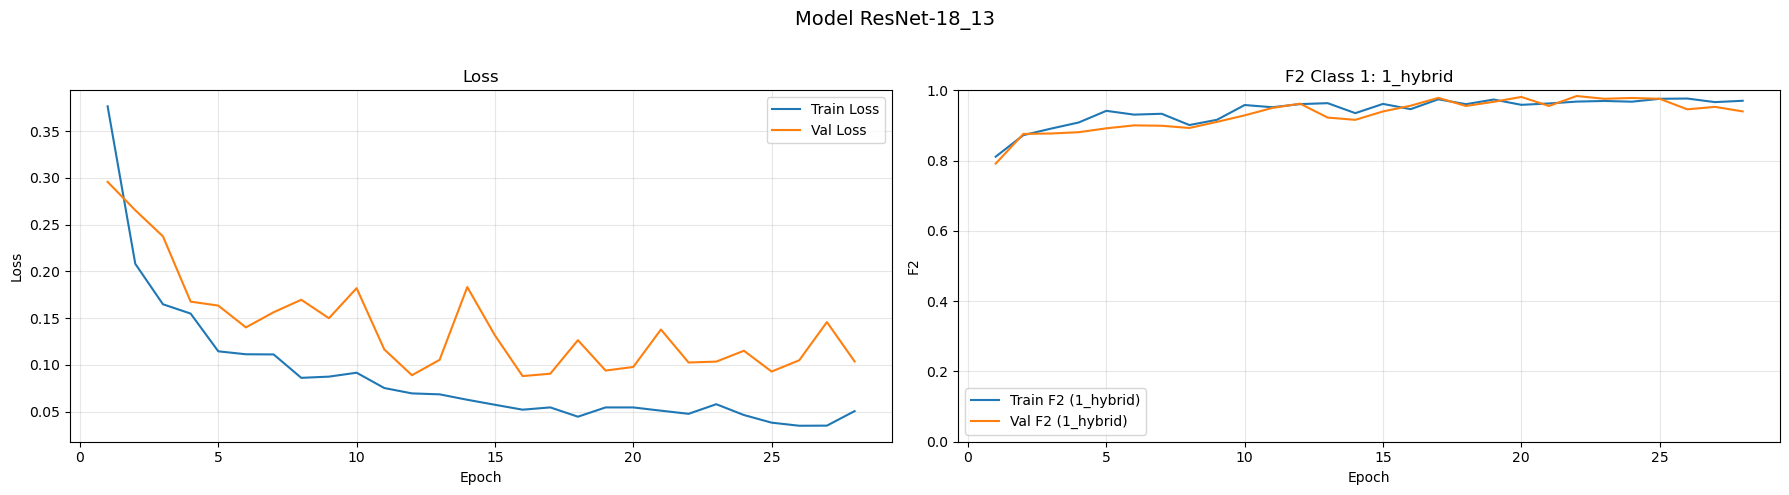

In [9]:
for i in range(1, 14):
    plot_training_curves(model_name=f"Model ResNet-18_{i}", results=results_from_ckpt(model=model_resnet_18_dict[f"model_resnet_18_{i}"], ckpt_file=f"../../saved_models/resnet/resnet_18/resnet_model_18_{i}_log.pkl"), class_idx=1, class_name="1_hybrid")